In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import tensorflow as tf
print(tf.keras.__version__)

3.13.2


In [ ]:
import zipfile
import os

# Define the path to your zip file and the extraction directory
zip_file_path = '/content/drive/MyDrive/Copy of Copy of devnagari digit.zip'
extract_dir = './extracted_content'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        print(f"Contents of {zip_file_path}:")
        for name in zip_ref.namelist():
            print(f"- {name}")

        # Extract all contents to the specified directory
        zip_ref.extractall(extract_dir)
        print(f"\nSuccessfully extracted all files to '{extract_dir}'")

        # Example of extracting a single file (if you know its name)
        # If 'some_file_in_zip.txt' exists in the archive, you can extract it like this:
        # if 'some_file_in_zip.txt' in zip_ref.namelist():
        #     zip_ref.extract('some_file_in_zip.txt', extract_dir)
        #     print(f"Extracted 'some_file_in_zip.txt' to '{extract_dir}'")

except FileNotFoundError:
    print(f"Error: The file '{zip_file_path}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_path}' is not a valid zip file or is corrupted.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

# List the contents of the extracted directory to verify
print(f"\nContents of '{extract_dir}':")
if os.path.exists(extract_dir):
    for root, dirs, files in os.walk(extract_dir):
        level = root.replace(extract_dir, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files:
            print(f'{subindent}{f}')
else:
    print("Extraction directory does not exist.")


Streaming output truncated to the last 5000 lines.
                99611.png
                89398.png
                28809.png
                28876.png
                18526.png
                103307.png
                18529.png
                18513.png
                18492.png
                103368.png
                4709.png
                6793.png
                12275.png
                43527.png
                6795.png
                103331.png
                39528.png
                28867.png
                85661.png
                18522.png
                76340.png
                4718.png
                6811.png
                28955.png
                103415.png
                12389.png
                6815.png
                103374.png
                76331.png
                49230.png
                39503.png
                12372.png
                4681.png
                99531.png
                9522.png
                76294.png
                

#Task 1: Data Preparation
Loading the Data

• Download the provided folder that contains the Devnagari digits dataset.

• Use the Python Imaging Library (PIL) to load and read the image files from the dataset.

• Convert the images into Numpy arrays and normalize them to a range of 0-1.

• use train folder for training and test for testing.

• Extract the corresponding labels for each image.

Loading training data...
Loading testing data...
Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


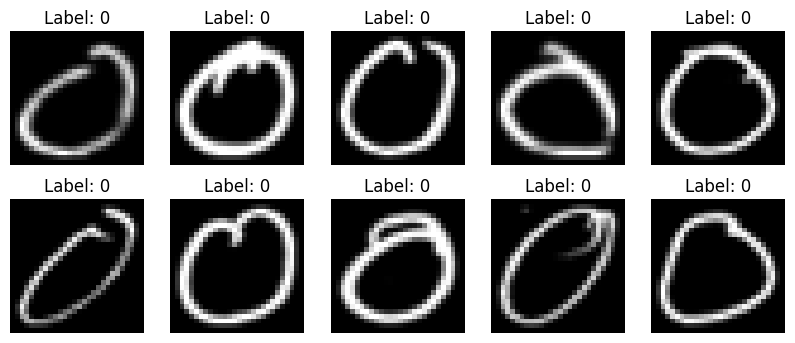

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image # Import Pillow

# Define dataset paths (corrected to point to extracted content)
train_dir = './extracted_content/DevanagariHandwrittenDigitDataset/Train/'
test_dir = './extracted_content/DevanagariHandwrittenDigitDataset/Test/'

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder)) # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)} # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            # Load image using PIL
            img = Image.open(img_path).convert("L") # Convert to grayscale
            img = img.resize((img_width, img_height)) # Resize to (28,28)
            img = np.array(img) / 255.0 # Normalize pixel values to [0,1]
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

print("Loading training data...")
# Load training and testing datasets (using X_train, y_train for consistency)
X_train_raw, y_train_raw = load_images_from_folder(train_dir)

print("Loading testing data...")
X_test_raw, y_test_raw = load_images_from_folder(test_dir)

# Reshape images for Keras input
X_train = X_train_raw.reshape(-1, img_height, img_width, 1) # Shape (num_samples, 28, 28, 1)
X_test = X_test_raw.reshape(-1, img_height, img_width, 1)

# One-hot encode labels (using y_train_cat, y_test_cat for consistency)
y_train_cat = to_categorical(y_train_raw, num_classes=10)
y_test_cat = to_categorical(y_test_raw, num_classes=10)

# Print dataset shape
print(f"Training set: {X_train.shape}, Labels: {y_train_cat.shape}")
print(f"Testing set: {X_test.shape}, Labels: {y_test_cat.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray') # Fixed smart quotes for cmap
    plt.title(f"Label: {np.argmax(y_train_cat[i])}")
    plt.axis("off")
plt.show()

#Task 2: Build the FCN Model
Model Architecture

• Create a Sequential model using Keras.

• Add 3 hidden layers with the following number of neurons:

– 1st hidden layer: 64 neurons

– 2nd hidden layer: 128 neurons

– 3rd hidden layer: 256 neurons

• Use sigmoid activation functions for all hidden layers.

• Add an output layer with 10 units with softmax (since Devnagari digits have 10 classes) and a
softmax activation function.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Build the FCN model
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),  # Flatten the 28x28 images into a 784-dimensional vector
    Dense(64, activation='sigmoid'),    # 1st hidden layer
    Dense(128, activation='sigmoid'),   # 2nd hidden layer
    Dense(256, activation='sigmoid'),   # 3rd hidden layer
    Dense(10, activation='softmax')     # Output layer for 10 classes
])

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

#Task 3: Compile the Model

Model Compilation

• Choose an appropriate optimizer (e.g., Adam), loss function (e.g., sparse categorical crossentropy),
and evaluation metric (e.g., accuracy).

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Task 4: Train the Model
Model Training

• Use the model.fit() function to train the model. Set the batch size to 128 and the number of
epochs to 20.

• Use validation split (validation split=0.2) to monitor the model’s performance on validation
data.

• Optionally, use callbacks such as ModelCheckpoint and EarlyStopping for saving the best model
and avoiding overfitting.

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
# ModelCheckpoint to save the best model based on validation accuracy
checkpoint_filepath = './best_model.weights.h5'
model_checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

# EarlyStopping to stop training if validation accuracy doesn't improve for a few epochs
early_stopping_callback = EarlyStopping(
    monitor='val_accuracy',
    patience=5, # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True,
    verbose=1
)

batch_size = 128
epochs = 2000

# Train the model
history = model.fit(
    X_train, y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2, # Use 20% of the training data for validation
    callbacks=[model_checkpoint_callback, early_stopping_callback] # Add callbacks
)

Epoch 1/2000
101/107 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2390 - loss: 2.0254
Epoch 1: val_accuracy improved from None to 0.00000, saving model to ./best_model.weights.h5

Epoch 1: finished saving model to ./best_model.weights.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.4337 - loss: 1.6622 - val_accuracy: 0.0000e+00 - val_loss: 7.1834
Epoch 2/2000
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7782 - loss: 0.7356
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8101 - loss: 0.5815 - val_accuracy: 0.0000e+00 - val_loss: 8.3158
Epoch 3/2000
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8808 - loss: 0.3448
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8914 - loss: 0.3178 - val_accuracy: 0.0000e+00 - val_loss: 8.8550
Epoch 4/2000
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9300 - loss: 0.2321
Epoch 4: val_accuracy did not 

#Task 5: Evaluate the Model
Model Evaluation

• After training, evaluate the model using model.evaluate() on the test set to check the test
accuracy and loss.

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 2.1675
Test Accuracy: 0.5773


#Task 6: Save and Load the Model
Model Saving and Loading

• Save the trained model to an .h5 file using model.save().

• Load the saved model and re-evaluate its performance on the test set.

In [ ]:
import tensorflow as tf

# 1. Save the trained model
model_save_path = './fcn_devanagari_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# 2. Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)
print("Model loaded successfully!")

# Display summary of the loaded model to verify
loaded_model.summary()

# 3. Re-evaluate the loaded model's performance on the test set
loaded_loss, loaded_accuracy = loaded_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"\nLoaded Model Test Loss: {loaded_loss:.4f}")
print(f"Loaded Model Test Accuracy: {loaded_accuracy:.4f}")

Model saved to ./fcn_devanagari_model.h5
Model loaded successfully!


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)


Loaded Model Test Loss: 2.1675
Loaded Model Test Accuracy: 0.5773


#Task 7: Predictions

Making Predictions

• Use model.predict() to make predictions on test images.

• Convert the model’s predicted probabilities to digit labels using np.argmax().

In [ ]:
import numpy as np

# Make predictions on the test set using the loaded model
predictions = loaded_model.predict(X_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

print(f"Shape of predictions (probabilities): {predictions.shape}")
print(f"Shape of predicted labels: {predicted_labels.shape}")

# Display the first 10 predicted labels and compare with actual labels
print("\nFirst 10 Predicted Labels:", predicted_labels[:10])
print("First 10 True Labels:", y_test_raw[:10])

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Shape of predictions (probabilities): (3000, 10)
Shape of predicted labels: (3000,)

First 10 Predicted Labels: [0 0 0 0 0 0 0 0 0 0]
First 10 True Labels: [0 0 0 0 0 0 0 0 0 0]


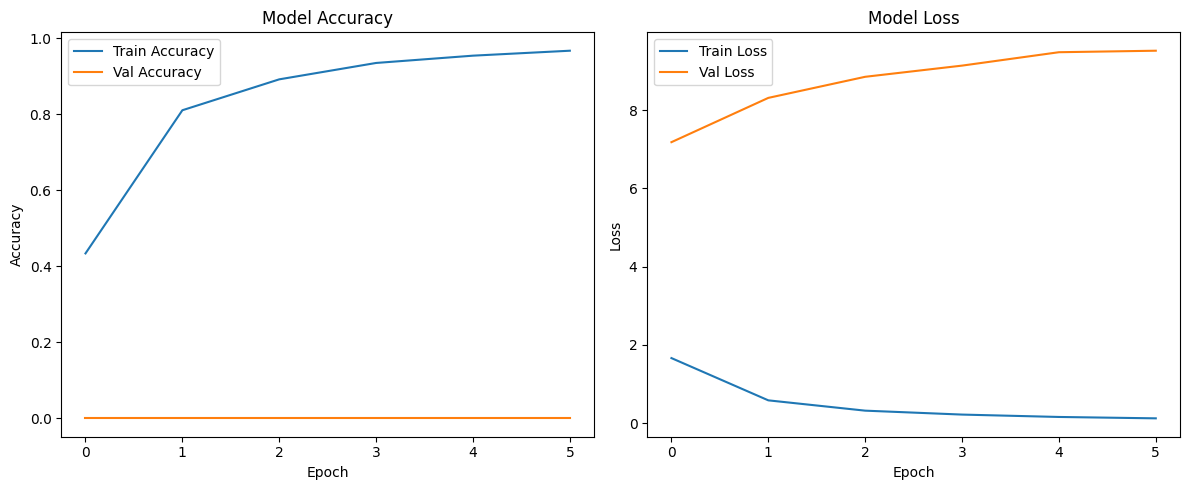


--- Final Deliverable ---
Final Test Accuracy: 0.5773
Model File Saved At: ./fcn_devanagari_model.h5


In [ ]:
import matplotlib.pyplot as plt

# Visualization: Graphs showing the training and validation loss and accuracy
plt.figure(figsize=(12, 5))

# Plot Training & Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Training & Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Display the final test accuracy as requested in deliverables
print(f"\n--- Final Deliverable ---")
print(f"Final Test Accuracy: {accuracy:.4f}")
print(f"Model File Saved At: {model_save_path}")